In [1]:
import itertools

import numpy as np
import seaborn as sns
from matplotlib import collections, colormaps, legend_handler, patches
from matplotlib import pyplot as plt
from scipy import linalg, optimize

from nustattools import plotting as nuplt

In [2]:
rng = np.random.default_rng()

In [3]:
# Create a random correlated covariance matrix
N = 3
cov = np.eye(N)
for i in range(N):
    u = rng.normal(size=N)
    u /= np.linalg.norm(u)
    if i >= 0:
        u *= (i + 1) ** 2
    u = u[:, np.newaxis]
    cov += u @ u.T

In [4]:
err = np.sqrt(np.diag(cov))
cor = cov / err[:, np.newaxis] / err[np.newaxis, :]
np.linalg.svd(cov, compute_uv=False), np.linalg.svd(cor, compute_uv=False)

(array([87.54334223, 12.44272566,  1.01393211]),
 array([2.48589853, 0.48468852, 0.02941295]))

(<matplotlib.collections.PatchCollection at 0x7f2a96fbc8b0>,
 <matplotlib.collections.PatchCollection at 0x7f2a96fbc790>)

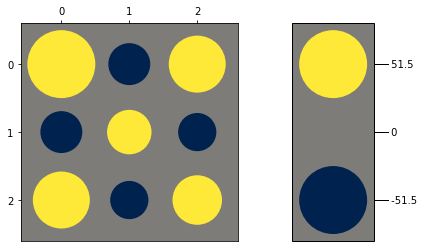

In [5]:
nuplt.hinton(cov, legend=True)

(<matplotlib.collections.PatchCollection at 0x7f2a94eb06d0>,
 <matplotlib.collections.PatchCollection at 0x7f2a94eb05e0>)

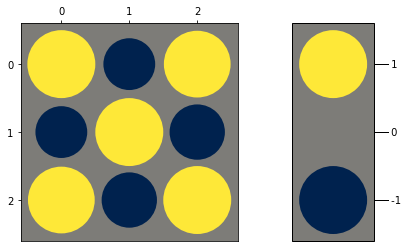

In [6]:
nuplt.hinton(cor, legend=True)

In [7]:
# Generate some random data
x = np.arange(0, N)
y = rng.multivariate_normal([0] * N, cov)
y

array([ 3.68508127, -4.2196489 ,  5.24461469])

Text(0, 0.5, 'y')

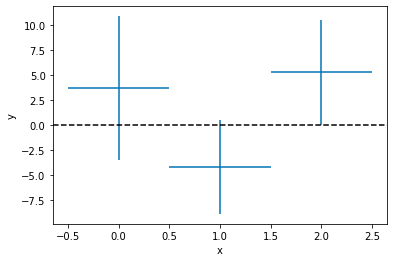

In [8]:
plt.errorbar(x, y, yerr=np.sqrt(np.diag(cov)), xerr=0.5, fmt=" ")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")

Text(0, 0.5, 'y')

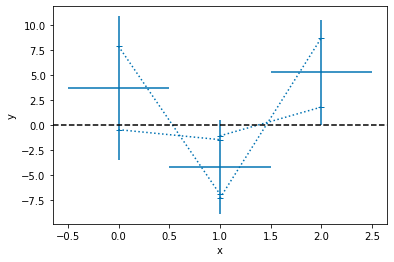

In [9]:
bars = nuplt.corlines(x, y, cov, xerr=0.5, corlinestyle=":")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")

Text(0, 0.5, 'y')

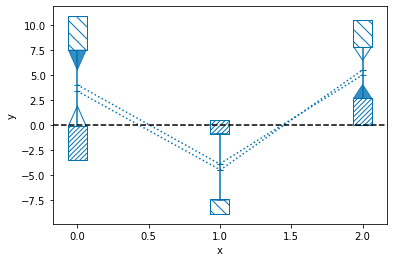

In [13]:
ret = {}
nuplt.pcplot(x, y, cov, return_dict=ret, scaling="second")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")

In [14]:
ret

{'K': array([[14.4293717 ,  1.03447313,  8.42858013],
        [ 1.03447313, 10.60470681, -0.82661203],
        [ 8.42858013, -0.82661203,  6.53497526]]),
 'u': array([-6.0912683 ,  3.38881047, -4.56545292]),
 'w': array([-0.67051176,  0.1004409 ,  0.73506843]),
 'yconderr': array([1.80465084, 3.36231727, 1.21041761])}

-8.919515196489064 10.863724675520963


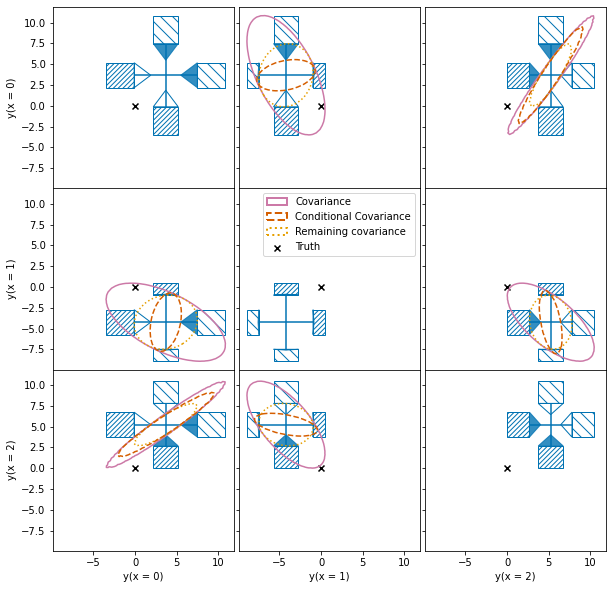

In [16]:
fig, axs = plt.subplots(
    N,
    N,
    sharex="col",
    sharey="row",
    figsize=(10, 10),
    gridspec_kw=dict(wspace=0, hspace=0),
)
ymin = np.min(y - err)
ymax = np.max(y + err)
print(ymin, ymax)
xx, yy = list(zip(*itertools.product(np.linspace(ymin - 1, ymax + 1, 50), repeat=2)))
xx = np.array(xx)
yy = np.array(yy)

for ix, iy in itertools.product(range(N), repeat=2):
    # axs[iy][ix].set_adjustable("box")
    axs[iy][ix].set_aspect("equal", "box")

    if ix == 0:
        axs[iy, ix].set_ylabel(f"y(x = {x[iy]:.4g})")
    if iy == len(x) - 1:
        axs[iy, ix].set_xlabel(f"y(x = {x[ix]:.4g})")

    xycov = cov[(ix, iy), :][:, (ix, iy)]
    xyK = ret["K"][(ix, iy), :][:, (ix, iy)]
    xycondinv = np.linalg.inv(cov)[(ix, iy), :][:, (ix, iy)]

    if ix == iy:
        xycov[0, 1] = xycov[1, 0] = 0
        xyK[0, 1] = xyK[1, 0] = 0
        xycondinv[0, 1] = xycondinv[1, 0] = 0

    xerr = np.sqrt(xycov[0, 0])
    yerr = np.sqrt(xycov[-1, -1])
    xKerr = np.sqrt(xyK[0, 0])
    yKerr = np.sqrt(xyK[-1, -1])
    xyu = ret["u"][
        (ix, iy),
    ]
    xyw = ret["w"][
        (ix, iy),
    ]
    xconderr = ret["yconderr"][ix]
    yconderr = ret["yconderr"][iy]
    axs[iy][ix].errorbar(y[ix], y[iy], xerr=xKerr, yerr=yKerr, color="C0")

    # Covariance ellipse
    xycovinv = np.linalg.inv(xycov)
    dx = xx - y[ix]
    dy = yy - y[iy]
    dd = np.array((dx, dy)).T
    zz = (dd[..., np.newaxis, :] @ xycovinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if ix != iy:
        ell = axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C3")

    # Remaining covariance ellipse
    xyKinv = np.linalg.inv(xyK)
    zz = (dd[..., np.newaxis, :] @ xyKinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if ix != iy:
        pass
        axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C1", linestyles=":")

    # Conditional covariance ellipse
    zz = (dd[..., np.newaxis, :] @ xycondinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if ix != iy:
        axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C2", linestyles="--")

    # 1st component boxes
    xw = yw = 3
    patch = patches.Rectangle(
        (y[ix] - xerr, y[iy] - yw / 2),
        xerr - xKerr,
        yw,
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[0] < 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)
    patch = patches.Rectangle(
        (y[ix] + xerr, y[iy] - yw / 2),
        -(xerr - xKerr),
        yw,
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[0] >= 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)
    patch = patches.Rectangle(
        (y[ix] - xw / 2, y[iy] - yerr),
        xw,
        yerr - yKerr,
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[1] < 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)
    patch = patches.Rectangle(
        (y[ix] - xw / 2, y[iy] + yerr),
        xw,
        -(yerr - yKerr),
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[1] >= 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)

    # Last component triangles
    patch = patches.Polygon(
        [
            (y[ix] - xKerr, y[iy] - yw / 2),
            (y[ix] - xconderr, y[iy]),
            (y[ix] - xKerr, y[iy] + yw / 2),
        ],
        edgecolor="C0",
    )
    if xyw[0] < 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)
    patch = patches.Polygon(
        [
            (y[ix] + xKerr, y[iy] - yw / 2),
            (y[ix] + xconderr, y[iy]),
            (y[ix] + xKerr, y[iy] + yw / 2),
        ],
        edgecolor="C0",
    )
    if xyw[0] >= 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)
    patch = patches.Polygon(
        [
            (y[ix] - xw / 2, y[iy] - yKerr),
            (y[ix], y[iy] - yconderr),
            (y[ix] + xw / 2, y[iy] - yKerr),
        ],
        edgecolor="C0",
    )
    if xyw[1] < 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)
    patch = patches.Polygon(
        [
            (y[ix] - xw / 2, y[iy] + yKerr),
            (y[ix], y[iy] + yconderr),
            (y[ix] + xw / 2, y[iy] + yKerr),
        ],
        edgecolor="C0",
    )
    if xyw[1] >= 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)

    # Truth
    tru = axs[iy][ix].scatter(0, 0, marker="x", color="k")

leg_artists = [
    patches.Ellipse((0, 0), 1, 1, linewidth=2, edgecolor="C3", linestyle="-", facecolor="none"),
    patches.Ellipse((0, 0), 1, 1, linewidth=2, edgecolor="C2", linestyle="--", facecolor="none"),
    patches.Ellipse((0, 0), 1, 1, linewidth=2, edgecolor="C1", linestyle=":", facecolor="none"),
    tru,
]
leg_labels = [
    "Covariance",
    "Conditional Covariance",
    "Remaining covariance",
    "Truth",
]
axs[1][1].legend(leg_artists, leg_labels)